In [16]:
# Example of chaotic migration using dynamical tides operator
import rebound
import reboundx
from matplotlib import pyplot as plt
import matplotlib
import numpy as np
matplotlib.rcParams.update({'font.size': 14})

# intial conditions
a0 = 1.5
e0 = 0.98
R_planet = 1.6 * 4.67e-4 # 1.6 Jupiter radii
m_planet = 1e-3 # approximately 1 Jupiter mass

# create simulation
sim = rebound.Simulation()
sim.add(m=1)
sim.add(m=m_planet, r=R_planet, a=a0, e=e0)

# load reboundx and the dynamical tides operator
rebx = reboundx.Extras(sim)
td = rebx.load_operator('tides_dynamical')
rebx.add_operator(td)

# set dP_crit = 0 to always carry out mode evolution
sim.particles[1].params['td_dP_crit'] = 0

# set initial modes to 0
sim.particles[1].params['td_c_imag'] = 0
sim.particles[1].params['td_c_real'] = 0

# debug
sim.particles[1].params['td_debug_delay'] = 0
sim.particles[1].params['td_debug_delay_counter'] = -1

# record initial orbital energy
o = sim.particles[1].orbit(primary=sim.particles[0])
EB0 = -sim.G * sim.particles[1].m * sim.particles[0].m / (2 * o.a)

N = 1000
t = np.linspace(0, 5e4, N) # time
a = np.zeros(N) # semi-major axis
e = np.zeros(N) # eccentricity
E = np.zeros(N) # mode energy
E_sim = np.zeros(N) # simulation energy
L = np.zeros((N, 3)) # total angular momentum

for i, time in enumerate(t):
    o = sim.particles[1].orbit(primary=sim.particles[0])
    a[i] = o.a
    e[i] = o.e
    L[i, :] = sim.angular_momentum() 
    E[i] = abs(EB0) * (sim.particles[1].params['td_c_imag']**2 + sim.particles[1].params['td_c_real']**2)
    E_sim[i] = sim.energy()

    if i % 100 == 0 and i != 0:
        print(time, o.a, o.e, E[i], sim.particles[1].params['td_dP_hat'])
    
    sim.integrate(2 * np.pi * time)
    



5005.005005005005 0.8094856363600326 0.9626110684878353 8.725664997825991e-06 47.038902277504064
10010.01001001001 0.3551385050955642 0.9125466087750176 2.3436716593760207e-06 2.2272618733707183
15015.015015015017 0.3252822064031731 0.9040958660842516 1.1987860136157788e-06 1.1573793083348316
20020.02002002002 0.32528220615176046 0.9040958660041918 1.1987882136286524e-06 1.1573796788709043
25025.02502502503 0.3252822057669943 0.9040958658872742 1.1987914844284073e-06 1.157380210985882
30030.030030030033 0.3252822064816897 0.9040958661132691 1.1987853237122398e-06 1.1573792011390593
35035.035035035035 0.32528220804617425 0.9040958666093847 1.1987718570784473e-06 1.1573769965450385
40040.04004004004 0.32535865710691253 0.9041195959388452 8.375955040880691e-07 1.1807082510559703
45045.04504504505 0.32535865777077944 0.9041195961439354 8.375978322550173e-07 1.1807136636785562


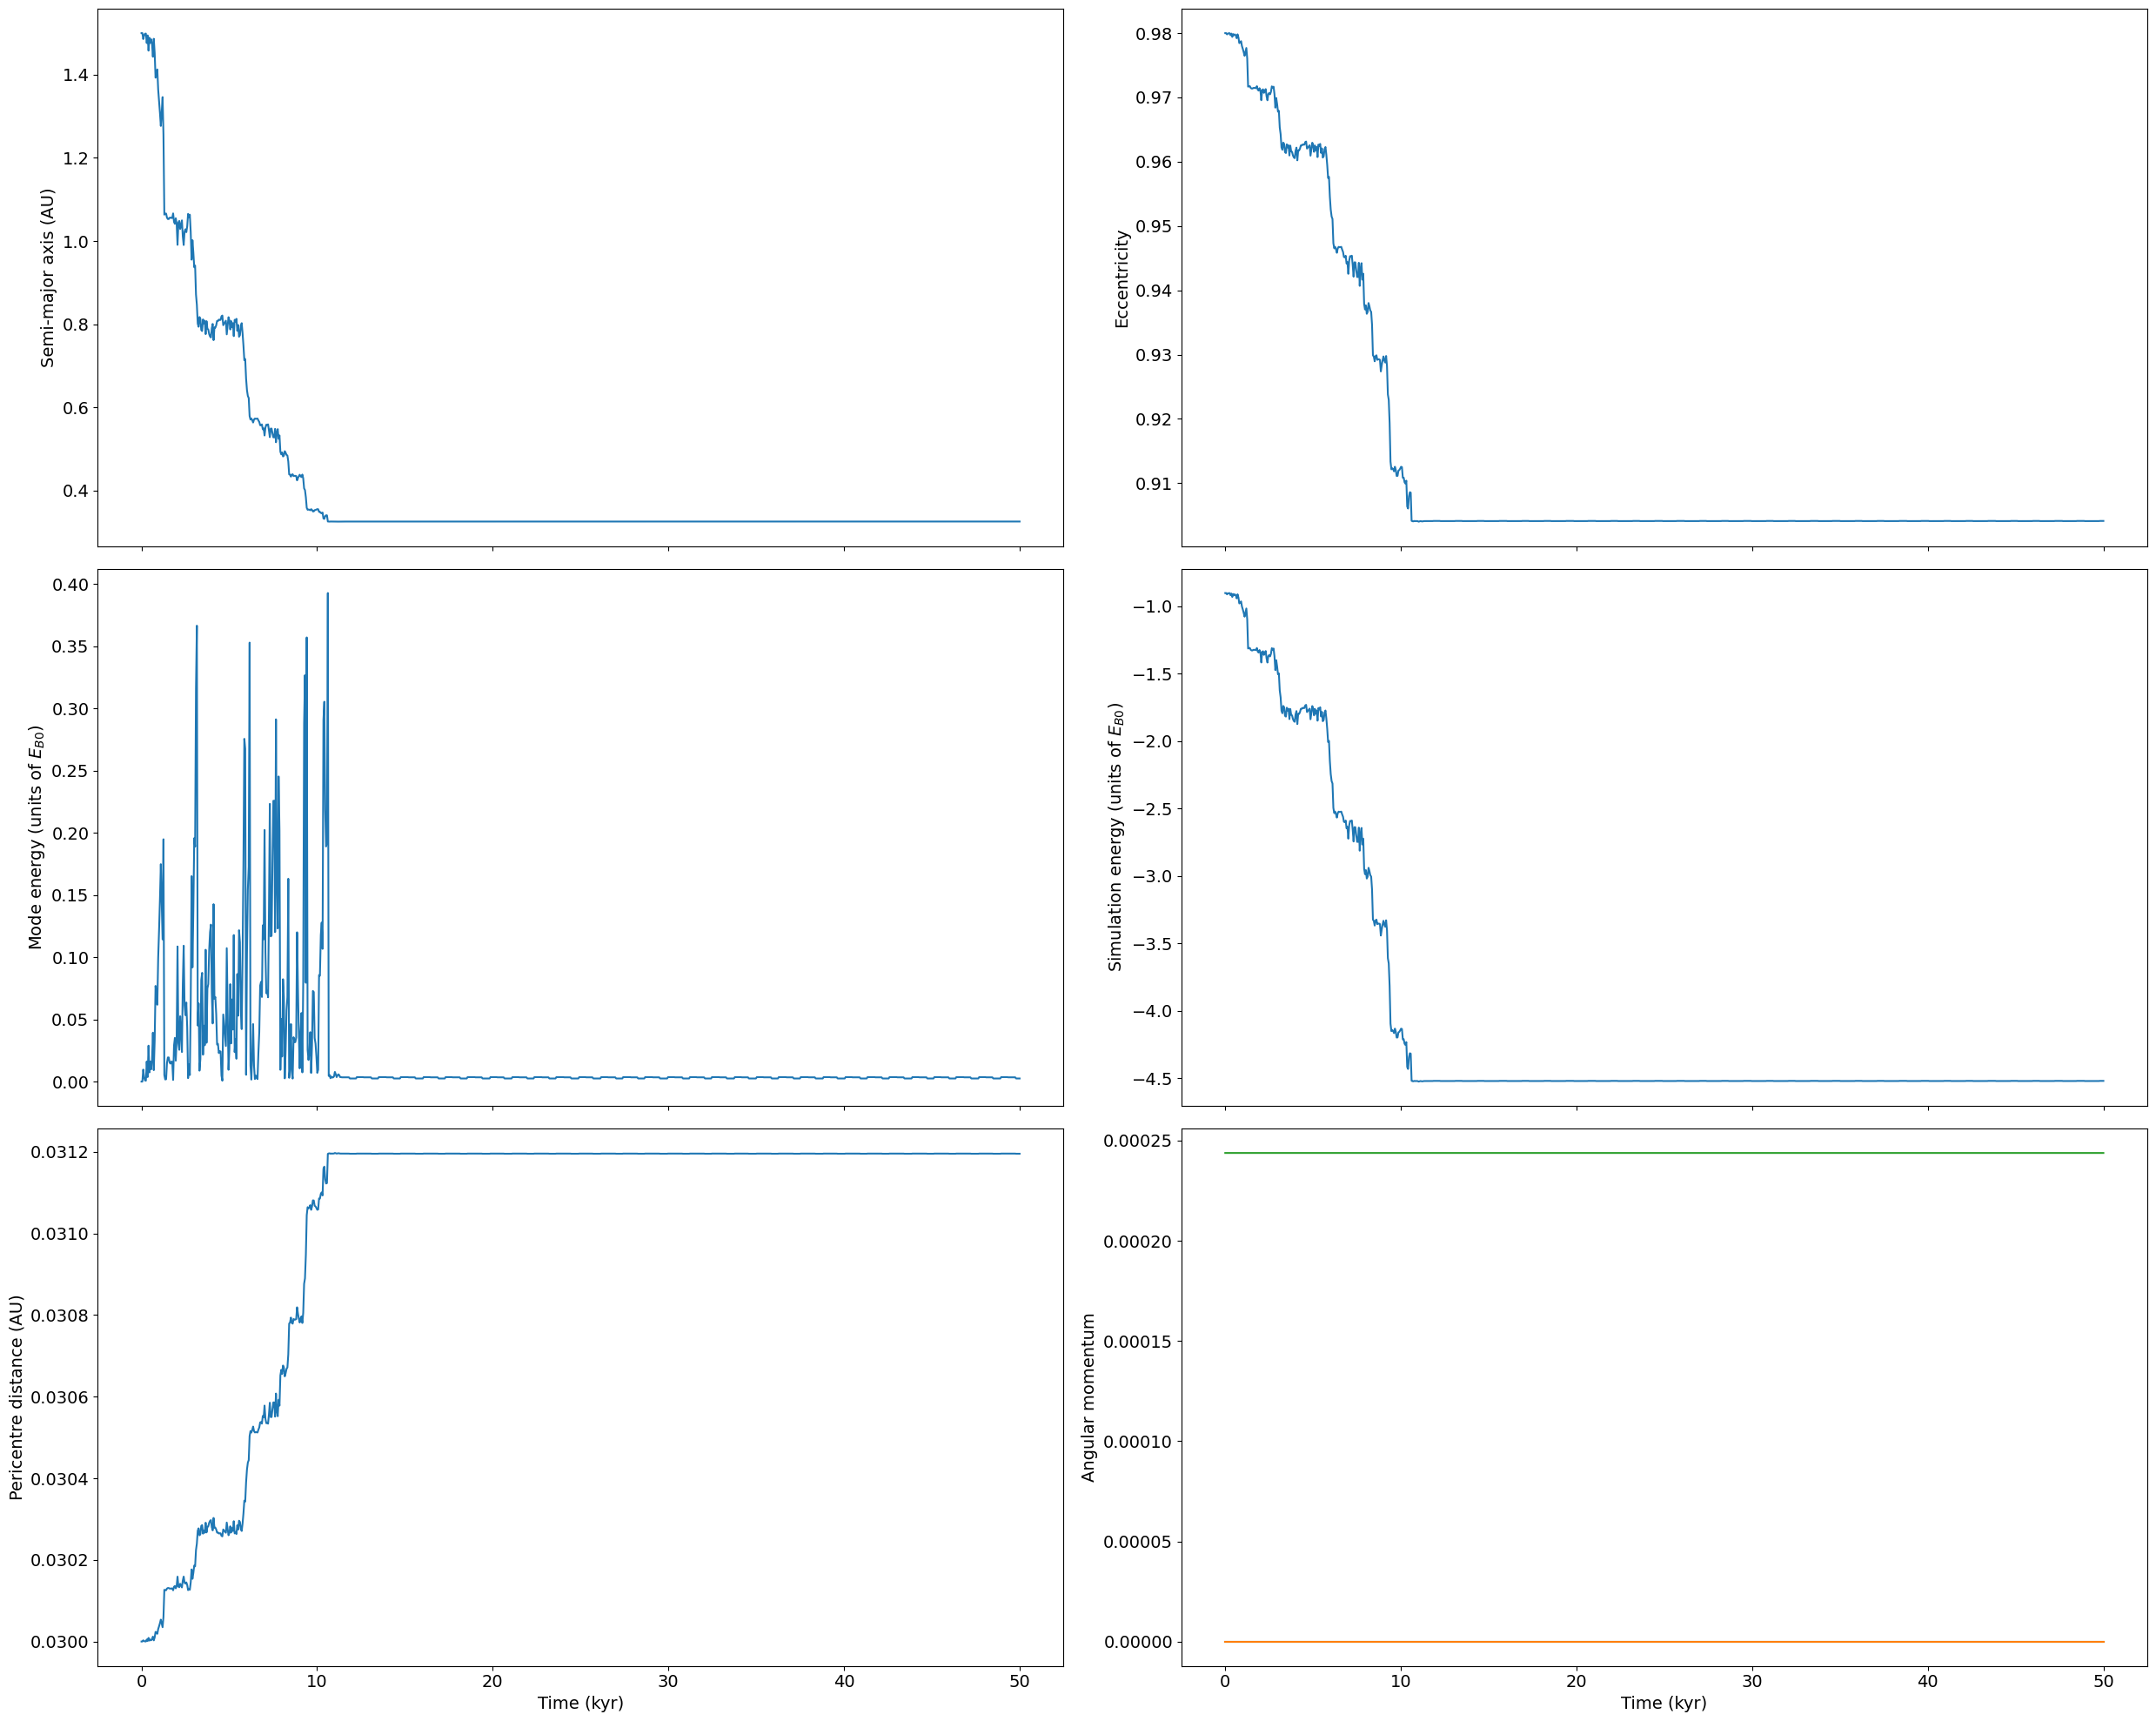

In [17]:
fig, axes = plt.subplots(3, 2, sharex=True)
fig.set_figheight(20)
fig.set_figwidth(25)


axes[0, 0].plot(t / 1e3, a)
axes[0, 0].set_ylabel(r'Semi-major axis (AU)')

axes[0, 1].plot(t / 1e3, e)
axes[0, 1].set_ylabel(r'Eccentricity')

axes[1, 0].plot(t / 1e3, -E / EB0)
axes[1, 0].set_ylabel(r'Mode energy (units of $E_{B0}$)')

axes[1, 1].plot(t / 1e3, -E_sim / EB0)
axes[1, 1].set_ylabel(r'Simulation energy (units of $E_{B0}$)')

axes[2, 0].plot(t / 1e3, a * (1-e))
axes[2, 0].set_ylabel(r'Pericentre distance (AU)')
axes[2, 0].set_xlabel(r'Time (kyr)')

axes[2, 1].plot(t / 1e3, L[:,0])
axes[2, 1].plot(t / 1e3, L[:,1])
axes[2, 1].plot(t / 1e3, L[:,2])
axes[2, 1].set_ylabel('Angular momentum')
axes[2, 1].set_xlabel(r'Time (kyr)')

plt.tight_layout()
plt.savefig("timeseries_delay_0.png", dpi=150)
